In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def calculate_glcm(image, m, n, gray_levels=256):
    """
    Calculate the Gray-Level Co-occurrence Matrix (GLCM) for a given displacement (m, n).
    
    Parameters:
    - image: 2D numpy array, the input grayscale image.
    - m: int, horizontal displacement.
    - n: int, vertical displacement.
    - gray_levels: int, the number of gray levels in the image (default is 256 for 8-bit images).
    
    Returns:
    - glcm: 2D numpy array, the calculated GLCM matrix.
    """
    # Ensure the image is quantized to the given gray levels
    image = np.clip(image, 0, gray_levels - 1)
    
    # Initialize the GLCM matrix
    glcm = np.zeros((gray_levels, gray_levels), dtype=np.float64)
    
    # Get the image dimensions
    rows, cols = image.shape
    
    # Iterate over the image to compute GLCM
    for i in range(rows - n):  # Ensure we don't go out of bounds vertically
        for j in range(cols - m):  # Ensure we don't go out of bounds horizontally
            row_pixel = image[i, j]  # Gray level of the current pixel
            col_pixel = image[i + n, j + m]  # Gray level of the displaced pixel
            
            # Increment the corresponding entry in the GLCM matrix
            glcm[row_pixel, col_pixel] += 1
    
    # Normalize the GLCM matrix
    glcm /= np.sum(glcm)
    
    return glcm

# Example usage with a test image
test_image = np.array([
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
], dtype=np.uint8)

m, n = 1, 0  # Horizontal displacement of 1, vertical displacement of 0 (horizontal direction)
glcm_result = calculate_glcm(test_image, m, n, gray_levels=2)

glcm_result


array([[0.        , 0.33333333],
       [0.33333333, 0.33333333]])

In [24]:
lena = Image.open('female.jpg')
lena_gray = lena.convert("L")
lena_array = np.array(lena_gray)
lena_array.shape

(678, 474)

In [25]:
m,n = 1,1
glcm_result11 = calculate_glcm(lena_array, m, n, gray_levels=256)
m,n = 2,2
glcm_result22 = calculate_glcm(lena_array, m, n, gray_levels=256)
m,n = 3,3
glcm_result33 = calculate_glcm(lena_array, m, n, gray_levels=256)


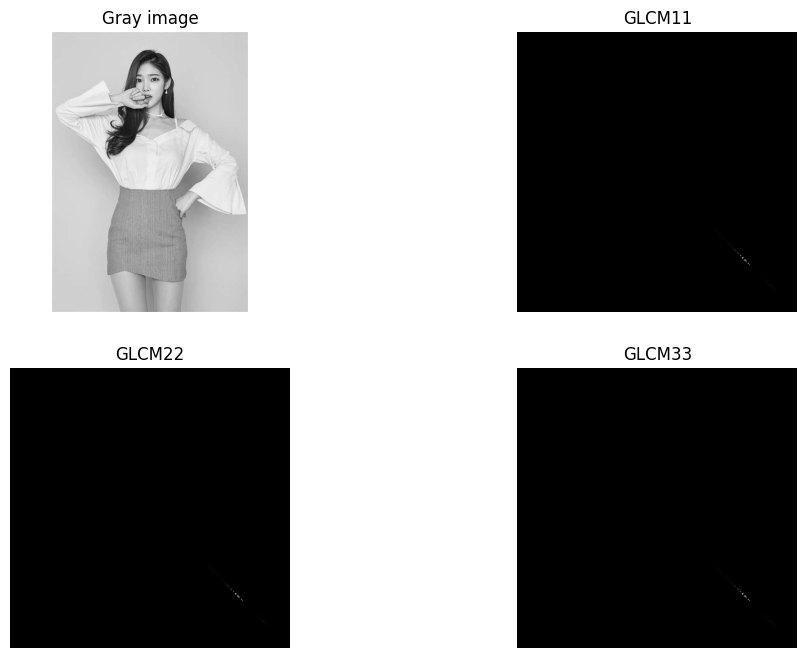

In [26]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)

plt.imshow(lena_gray,cmap='gray')
plt.axis('off')
plt.title('Gray image')

plt.subplot(2,2,2)
plt.imshow(glcm_result11,cmap='gray')
plt.axis('off')
plt.title('GLCM11')

plt.subplot(2,2,3)
plt.imshow(glcm_result22,cmap='gray')
plt.axis('off')
plt.title('GLCM22')

plt.subplot(2,2,4)
plt.imshow(glcm_result33,cmap='gray')
plt.axis('off')
plt.title('GLCM33')
plt.show()
